# DA2-MODEL-03 — Gradient Boosting + So sánh mô hình

> **Yêu cầu:** Chạy `DA2-MODEL-01` và `DA2-MODEL-02` trước

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train_sc = np.load('/home/jovyan/work/sv4/shared/X_train_sc.npy')
X_test_sc  = np.load('/home/jovyan/work/sv4/shared/X_test_sc.npy')
y_train    = np.load('/home/jovyan/work/sv4/shared/y_train.npy')
y_test     = np.load('/home/jovyan/work/sv4/shared/y_test.npy')
y_pred_rf  = np.load('/home/jovyan/work/sv4/shared/y_pred_rf.npy')

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Train: (792, 7) | Test: (198, 7)


      GRADIENT BOOSTING - KẾT QUẢ
              precision    recall  f1-score   support

    Sell (0)       0.38      0.32      0.35        78
     Buy (1)       0.60      0.66      0.63       120

    accuracy                           0.53       198
   macro avg       0.49      0.49      0.49       198
weighted avg       0.51      0.53      0.52       198



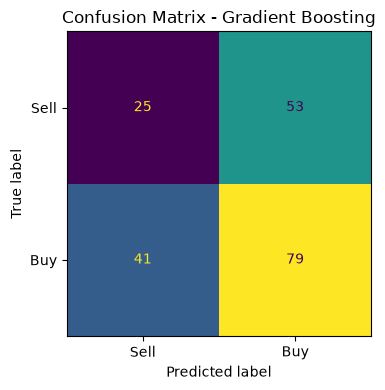

In [5]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_sc, y_train)
y_pred_gb = gb.predict(X_test_sc)

print('=' * 45)
print('      GRADIENT BOOSTING - KẾT QUẢ')
print('=' * 45)
print(classification_report(y_test, y_pred_gb, target_names=['Sell (0)', 'Buy (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb),
                       display_labels=['Sell', 'Buy']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Gradient Boosting')
plt.tight_layout()
plt.show()

                   Accuracy  Precision  Recall  F1-Score
Model                                                   
Random Forest        0.6768     0.6573  0.9750    0.7852
Gradient Boosting    0.5253     0.5985  0.6583    0.6270


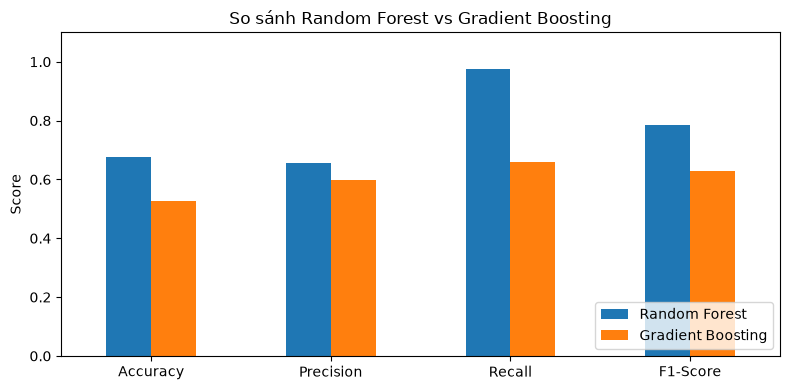


Mô hình tốt nhất theo F1-Score: Random Forest


In [6]:
# So sánh 2 mô hình
results = pd.DataFrame({
    'Model'    : ['Random Forest', 'Gradient Boosting'],
    'Accuracy' : [accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_gb)],
    'Precision': [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_gb)],
    'Recall'   : [recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred_gb)],
    'F1-Score' : [f1_score(y_test, y_pred_rf),        f1_score(y_test, y_pred_gb)],
}).set_index('Model').round(4)

print(results.to_string())

results.T.plot(kind='bar', figsize=(8, 4), rot=0)
plt.title('So sánh Random Forest vs Gradient Boosting')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/home/jovyan/work/sv4/DA2-MODEL-03/Model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = results['F1-Score'].idxmax()
print(f'\nMô hình tốt nhất theo F1-Score: {best}')